In [2]:
# Install the necessary libraries
!pip install tensorflow

Access is denied.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

In [4]:
# 1. Dataset Generation
X, y = make_classification(
    n_samples=1000, 
    n_features=5, 
    n_informative=5, 
    n_redundant=0, 
    n_classes=5, 
    random_state=42
)

In [5]:

# Preprocessing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert labels to one-hot encoding for multiclass
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)


In [6]:
# 2. Model Architecture
model = Sequential([
    Dense(5, activation='relu', input_shape=(5,)), # Hidden Layer 1
    Dense(4, activation='relu'),                   # Hidden Layer 2
    Dense(3, activation='relu'),                   # Hidden Layer 3
    Dense(5, activation='softmax')                 # Output Layer
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


c:\Users\dell\miniconda3\envs\python_basics\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# 3. Training
history = model.fit(
    X_train, y_train_cat, 
    validation_data=(X_test, y_test_cat), 
    epochs=100, 
    batch_size=32, 
    verbose=0
    
)

In [8]:

# 4. Evaluation
train_loss, train_acc = model.evaluate(X_train, y_train_cat, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Accuracy: 0.5600
Test Accuracy: 0.5550


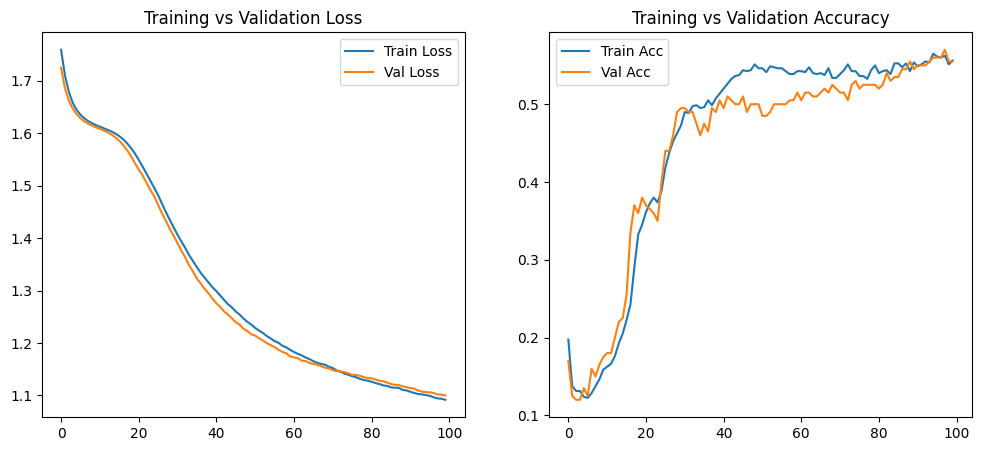

In [9]:
# 5. Visualization
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()
